# Dataset Analysis
Generates publication-quality figures for the dataset section of the paper.

**Figures produced:**
1. Class distribution (bar + pie)
2. Train / Val / Test split comparison
3. Sample image grid (dyslexic vs normal)
4. Pixel intensity distribution

In [1]:
import os
from pathlib import Path
# Always run from project root so relative paths work
os.chdir(Path(__file__).parent if "__file__" in dir() else Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
import sys
sys.path.insert(0, '..')

import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from PIL import Image

DATA_DIR = Path('../data')
OUT_DIR  = Path('figures')
OUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
print('Setup complete.')

Setup complete.


In [2]:
# Count images in each split / class
counts = {}
for split in ['train', 'val', 'test']:
    counts[split] = {}
    for cls in ['dyslexic', 'normal']:
        p = DATA_DIR / split / cls
        counts[split][cls] = len(list(p.glob('*'))) if p.exists() else 0

for split, cls_counts in counts.items():
    total = sum(cls_counts.values())
    print(f'{split.upper():6s}: dyslexic={cls_counts["dyslexic"]:,}  '
          f'normal={cls_counts["normal"]:,}  total={total:,}')

TRAIN : dyslexic=95,468  normal=33,434  total=128,902
VAL   : dyslexic=16,847  normal=5,900  total=22,747
TEST  : dyslexic=37,136  normal=19,557  total=56,693


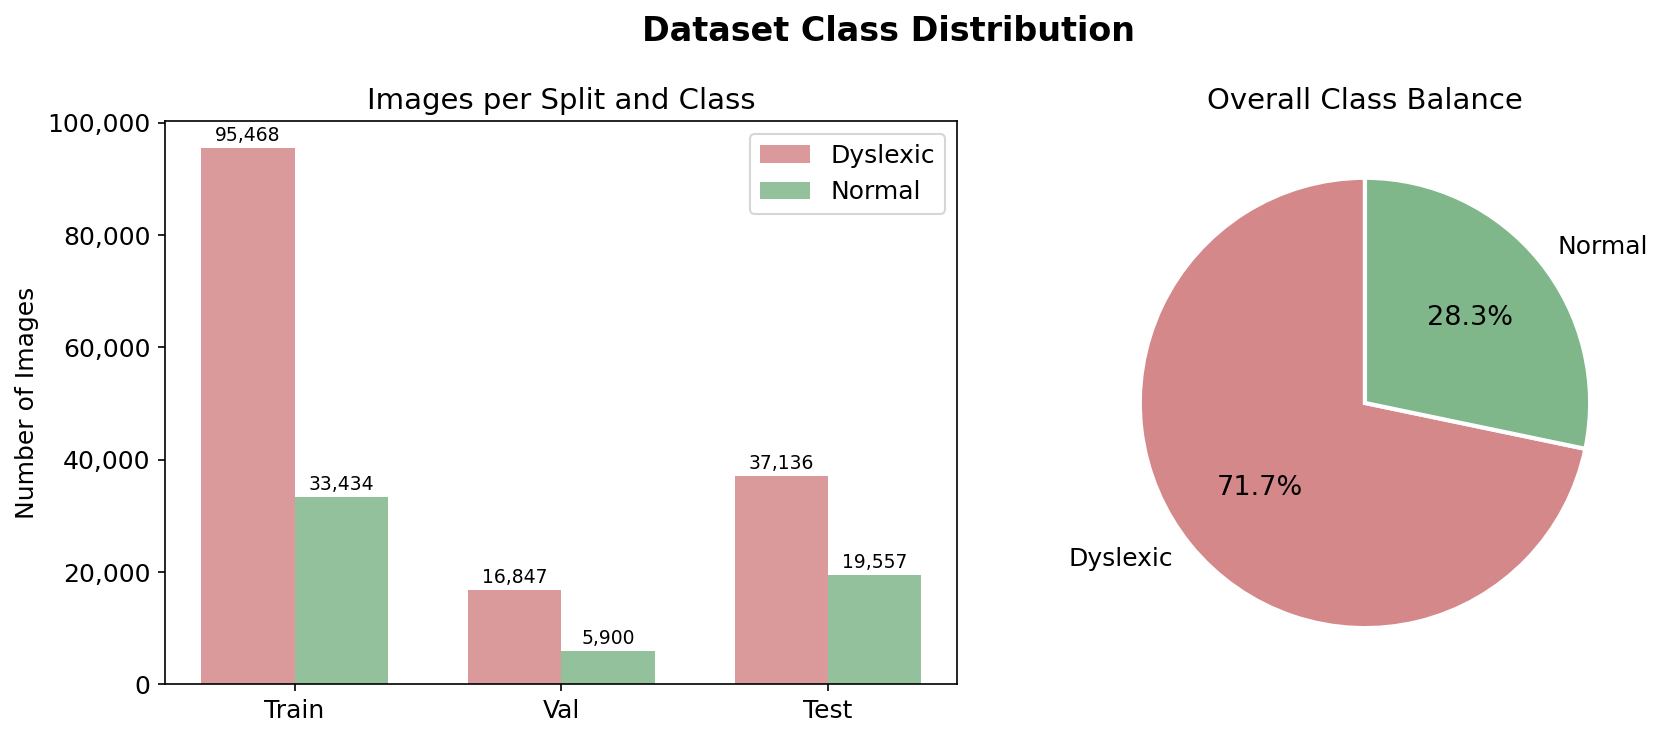

Saved fig1_class_distribution.png


In [3]:
# Figure 1 — Class distribution bar chart + pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Dataset Class Distribution', fontsize=16, fontweight='bold')

splits = list(counts.keys())
dys_vals = [counts[s]['dyslexic'] for s in splits]
nor_vals = [counts[s]['normal']   for s in splits]
x = np.arange(len(splits))
w = 0.35

# Bar chart
ax = axes[0]
bars1 = ax.bar(x - w/2, dys_vals, w, label='Dyslexic', color='#D4888A', alpha=0.85)
bars2 = ax.bar(x + w/2, nor_vals, w, label='Normal',   color='#7FB68A', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in splits])
ax.set_ylabel('Number of Images')
ax.set_title('Images per Split and Class')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

# Pie chart (train set)
ax2 = axes[1]
total_dys = sum(counts[s]['dyslexic'] for s in splits)
total_nor = sum(counts[s]['normal']   for s in splits)
wedges, texts, autotexts = ax2.pie(
    [total_dys, total_nor],
    labels=['Dyslexic', 'Normal'],
    autopct='%1.1f%%',
    colors=['#D4888A', '#7FB68A'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
for at in autotexts:
    at.set_fontsize(13)
ax2.set_title('Overall Class Balance')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig1_class_distribution.png')
plt.show()
print('Saved fig1_class_distribution.png')

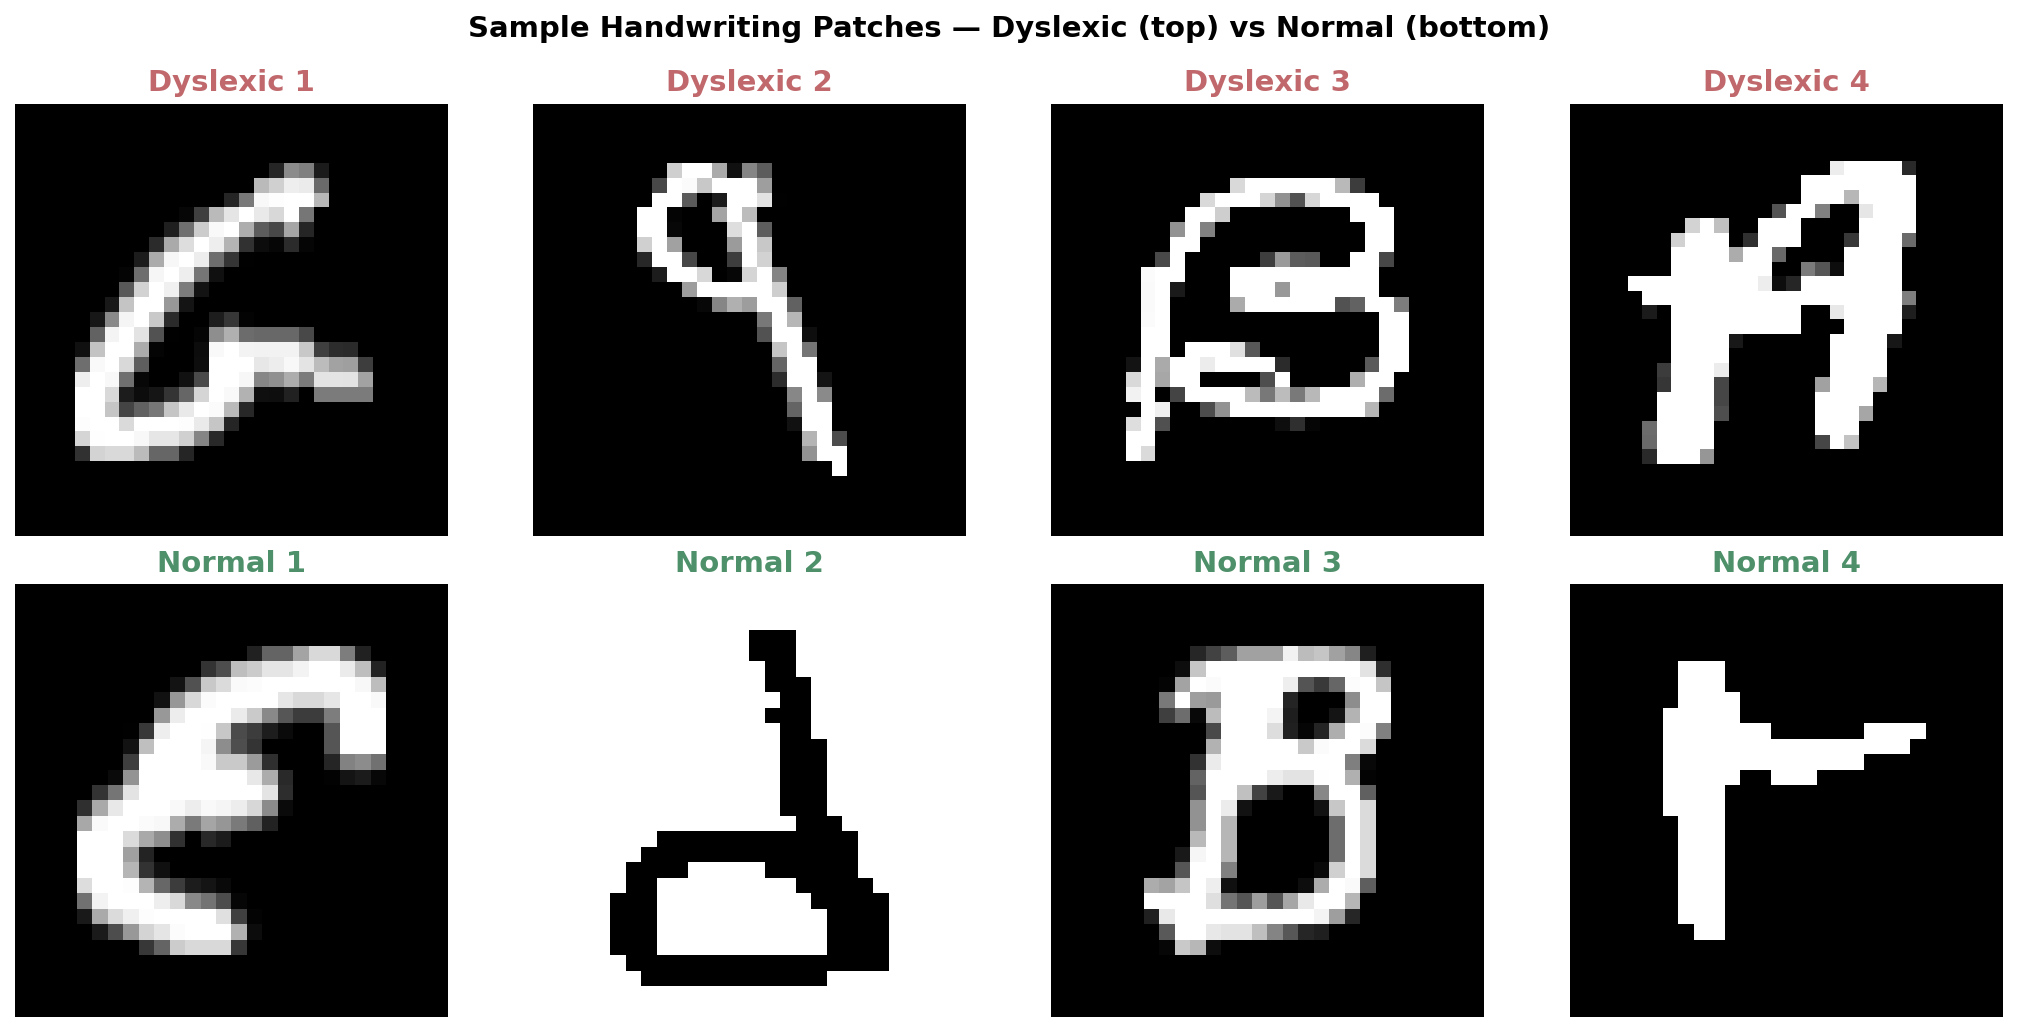

Saved fig2_sample_patches.png


In [4]:
# Figure 2 — Sample image grid (4 dyslexic + 4 normal)
def load_samples(cls: str, n: int = 4) -> list:
    imgs = []
    for split in ['train', 'val', 'test']:
        p = DATA_DIR / split / cls
        if p.exists():
            imgs.extend(list(p.glob('*.jpg')) + list(p.glob('*.png')))
    random.seed(42)
    return random.sample(imgs, min(n, len(imgs)))

dys_paths = load_samples('dyslexic', 4)
nor_paths = load_samples('normal',   4)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Sample Handwriting Patches — Dyslexic (top) vs Normal (bottom)',
             fontsize=14, fontweight='bold')

for col, path in enumerate(dys_paths):
    img = Image.open(path).convert('RGB')
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(f'Dyslexic {col+1}', color='#C0686B', fontweight='bold')
    axes[0, col].axis('off')

for col, path in enumerate(nor_paths):
    img = Image.open(path).convert('RGB')
    axes[1, col].imshow(img, cmap='gray')
    axes[1, col].set_title(f'Normal {col+1}', color='#4E906A', fontweight='bold')
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig2_sample_patches.png')
plt.show()
print('Saved fig2_sample_patches.png')

Loading pixel samples (this may take ~30s)...


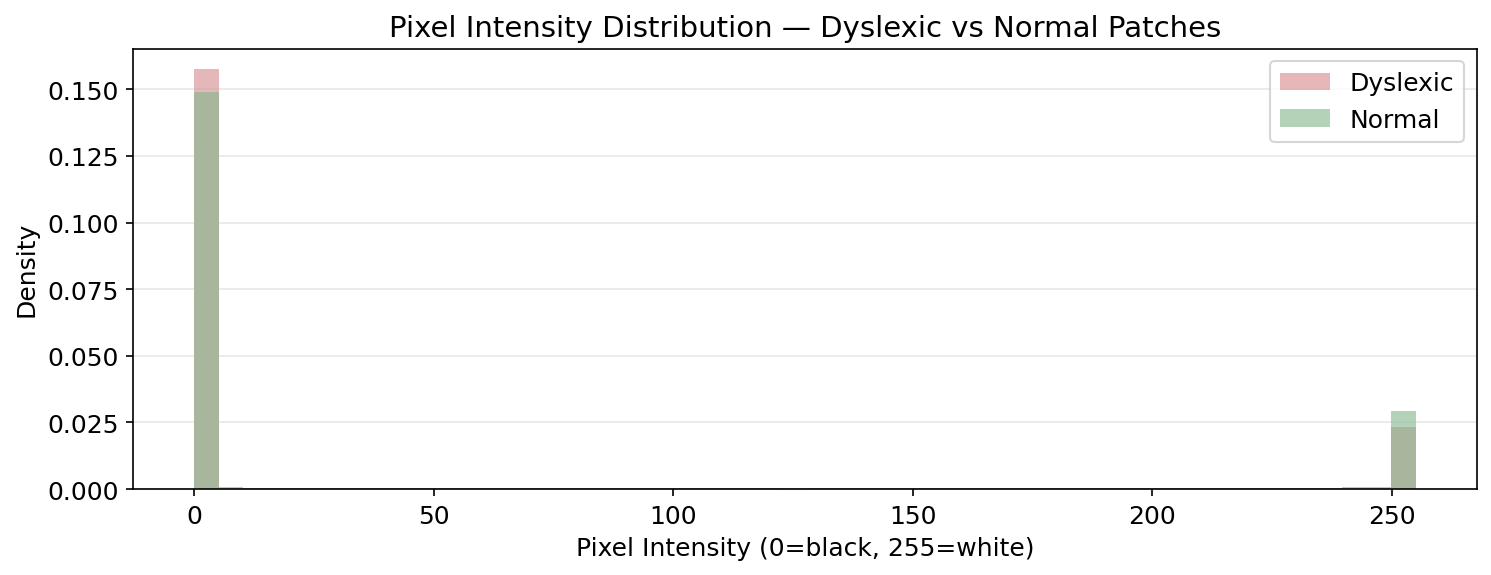

Saved fig3_pixel_distribution.png


In [5]:
# Figure 3 — Pixel intensity histogram (dyslexic vs normal)
def pixel_intensities(cls: str, n_samples: int = 200):
    all_pixels = []
    paths = load_samples(cls, n_samples)
    for p in paths:
        arr = np.array(Image.open(p).convert('L'))  # grayscale
        all_pixels.extend(arr.flatten().tolist())
    return np.array(all_pixels)

print('Loading pixel samples (this may take ~30s)...')
dys_px = pixel_intensities('dyslexic', 200)
nor_px = pixel_intensities('normal',   200)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dys_px, bins=50, alpha=0.6, color='#D4888A', label='Dyslexic', density=True)
ax.hist(nor_px, bins=50, alpha=0.6, color='#7FB68A', label='Normal',   density=True)
ax.set_xlabel('Pixel Intensity (0=black, 255=white)')
ax.set_ylabel('Density')
ax.set_title('Pixel Intensity Distribution — Dyslexic vs Normal Patches')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig3_pixel_distribution.png')
plt.show()
print('Saved fig3_pixel_distribution.png')

In [6]:
# Summary
total = sum(sum(cls.values()) for cls in counts.values())
print(f'\nDataset summary:')
print(f'  Total images : {total:,}')
print(f'  Train        : {sum(counts["train"].values()):,}')
print(f'  Val          : {sum(counts["val"].values()):,}')
print(f'  Test         : {sum(counts["test"].values()):,}')
print(f'\nFigures saved to: {OUT_DIR.resolve()}')


Dataset summary:
  Total images : 208,342
  Train        : 128,902
  Val          : 22,747
  Test         : 56,693

Figures saved to: C:\Users\ASUS\Desktop\Early-screening-of-dyslexia-\notebooks\figures
